In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[1], 'GPU')

import hmc_2hl as hmc

In [49]:
L = 2
als = np.array([1+1/6, 1+2/6, 1+3/6, 1+4/6, 1+5/6, 2, 2+1/3, 2+2/3, 3, 3+1/3, 3+2/3, 4]) * L

In [50]:
len(als)

12

In [ ]:
[4000, 6000, 8000, 2500]

In [45]:
d = 50
alpha = 3.66
gamma_1 = 1
gamma_2 = 1

Delta = 0.1
vlaw = 'ones'
k1 = int(gamma_1 * d)
k2 = int(gamma_2 * d)

sig_1 = lambda x: (tf.nn.tanh(2*x) - 0.729477*x) / 0.321129
sig_2 = lambda x: (tf.nn.tanh(2*x) - 0.729477*x) / 0.321129

params = {
    'step_size': 0.01,
    'num_leapfrog_steps': 10,
    'num_adaptation_steps': 2500,
}

ntest = 10000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32)


In [46]:
W10, W20, v, X, Y = hmc.data_generate(d, alpha, gamma_1, gamma_2, sig_1, sig_2, Delta, vlaw)
W1s_info, W2s_info = hmc.hmc(params, W10, W20, v, X, Y, Delta, sig_1, sig_2, info=True)
test_info = hmc.test_error(W1s_info, W2s_info, W10, W20, v, sig_1, sig_2, Xtest)

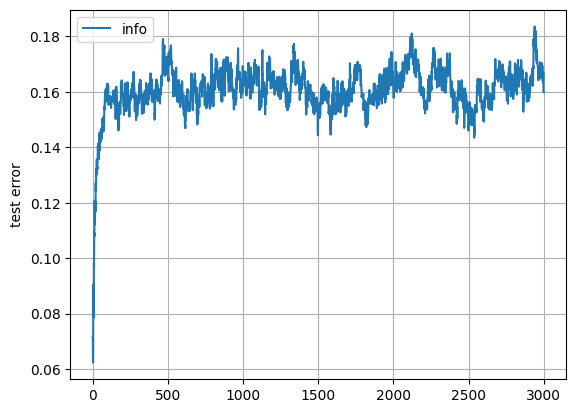

In [47]:
plt.plot(test_info, label='info')
plt.ylabel('test error')
plt.legend()
plt.grid()
plt.show()